In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load the Diabetes dataset
data = load_diabetes(as_frame=True)

df = data.frame

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
print("Features:")
print(data.feature_names)

print("\nTarget Variable:")
print("Disease Progression")

print("\nDataset Information:")
df.info()

Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target Variable:
Disease Progression

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [5]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


In [6]:
# Input Feature
X = df[["bmi"]]

# Target Variable
y = df["target"]

print("Input Feature:")
display(X.head())

print("Target Variable:")
display(y.head())

Input Feature:


,bmi
0,0.061696
1,-0.051474
2,0.044451
3,-0.011595
4,-0.036385


Target Variable:


,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 353
Testing Samples : 89


In [8]:
# Create the model
simple_model = LinearRegression()

# Train the model
simple_model.fit(X_train, y_train)

LinearRegression()

In [9]:
print("Intercept:", round(simple_model.intercept_, 4))
print("Slope   :", round(simple_model.coef_[0], 4))

print(
    f"\nDisease Progression = "
    f"{simple_model.intercept_:.4f} + "
    f"({simple_model.coef_[0]:.4f} × BMI)"
)

Intercept: 152.0034
Slope   : 998.5777

Disease Progression = 152.0034 + (998.5777 × BMI)


In [10]:
# Predict target values for test data
y_pred_simple = simple_model.predict(X_test)

print("First 10 Predictions:")
print(y_pred_simple[:10])

First 10 Predictions:
[145.80622687 188.85739048 147.95878505 203.92529774 131.8145987
 127.50948234 322.31599764 197.4676232   61.85645785 167.33180868]


In [11]:
mse_simple = mean_squared_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression Results")
print("--------------------------------")
print("Mean Squared Error:", round(mse_simple, 4))
print("R² Score          :", round(r2_simple, 4))

Simple Linear Regression Results
--------------------------------
Mean Squared Error: 4061.8259
R² Score          : 0.2334


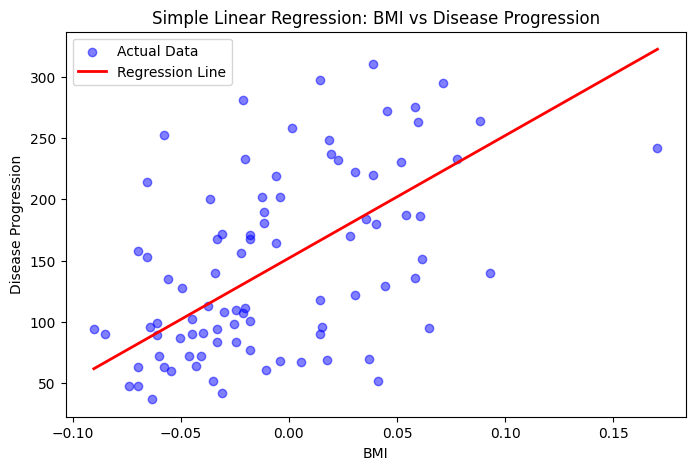

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test,
    y_test,
    color="blue",
    alpha=0.5,
    label="Actual Data"
)

# Sort BMI values for drawing the regression line
X_sorted = X_test.sort_values("bmi")

plt.plot(
    X_sorted,
    simple_model.predict(X_sorted),
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Simple Linear Regression: BMI vs Disease Progression")
plt.legend()
plt.show()

In [14]:
# Multiple LR
# Input features: all available features
X = df.drop("target", axis=1)

# Target variable
y = df["target"]

print("Input Features:")
display(X.head())

print("Target Variable:")
display(y.head())

Input Features:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


Target Variable:


,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 353
Testing Samples : 89


In [16]:
# Create the model
multiple_model = LinearRegression()

# Train the model
multiple_model.fit(X_train, y_train)

LinearRegression()

In [17]:
print("Intercept:", round(multiple_model.intercept_, 4))

print("\nCoefficients:")
for feature, coefficient in zip(X.columns, multiple_model.coef_):
    print(f"{feature}: {coefficient:.4f}")

Intercept: 151.3456

Coefficients:
age: 37.9040
sex: -241.9644
bmi: 542.4288
bp: 347.7038
s1: -931.4888
s2: 518.0623
s3: 163.4200
s4: 275.3179
s5: 736.1989
s6: 48.6707


In [18]:
# Predict target values for test data
y_pred_multiple = multiple_model.predict(X_test)

print("First 10 Predictions:")
print(y_pred_multiple[:10])

First 10 Predictions:
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]


In [19]:
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print("Multiple Linear Regression Results")
print("----------------------------------")
print("Mean Squared Error:", round(mse_multiple, 4))
print("R² Score          :", round(r2_multiple, 4))

Multiple Linear Regression Results
----------------------------------
Mean Squared Error: 2900.1936
R² Score          : 0.4526


In [20]:
comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MSE": [
        mse_simple,
        mse_multiple
    ],
    "R² Score": [
        r2_simple,
        r2_multiple
    ]
})

comparison

,Model,MSE,R² Score
0,Simple Linear Regression,4061.825928,0.233350
1,Multiple Linear Regression,2900.193628,0.452603


In [21]:
print("Model Performance Comparison")
print("============================")

print(f"Simple Linear Regression:")
print(f"MSE      : {mse_simple:.4f}")
print(f"R² Score : {r2_simple:.4f}")

print("\nMultiple Linear Regression:")
print(f"MSE      : {mse_multiple:.4f}")
print(f"R² Score : {r2_multiple:.4f}")

Model Performance Comparison
Simple Linear Regression:
MSE      : 4061.8259
R² Score : 0.2334

Multiple Linear Regression:
MSE      : 2900.1936
R² Score : 0.4526


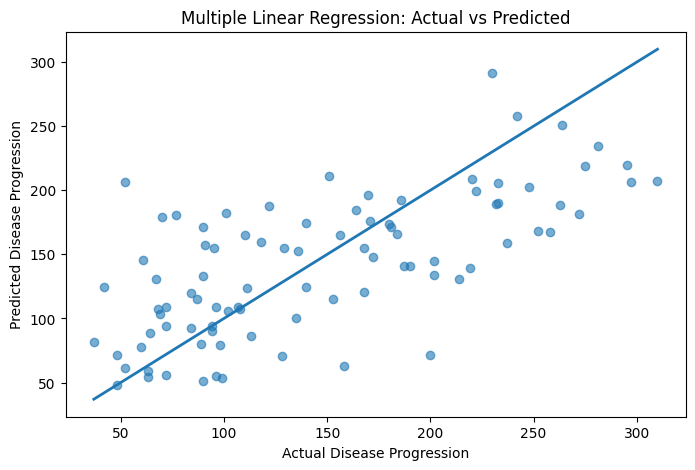

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred_multiple,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title("Multiple Linear Regression: Actual vs Predicted")

plt.show()


***Interpretation:***

Simple Linear Regression uses only BMI to predict disease progression.
The obtained MSE and R² score indicate how well BMI alone explains
the variation in disease progression.

Multiple Linear Regression uses all the available features such as age,
sex, BMI, blood pressure and six blood serum measurements. Since more
relevant information is provided to the model, its predictive performance
can be compared with the Simple Linear Regression model using MSE and R².

A lower MSE indicates better prediction accuracy, while a higher R² score
indicates that the model explains a larger proportion of the variation
in the target variable.

The comparison of the two models shows the difference between using
a single feature and using multiple features for predicting disease
progression.